# 公式 o13 — Multiary Complex Model of GPCR Signaling Activations

> **出典（E-Cell4 公式）**: Examples / example13 — https://ecell4.e-cell.org/examples/example13.html
>
> G タンパク質共役受容体(GPCR)の活性化を、受容体オリゴマー化の次数 N=0..5 の**多量体複合体モデル**で表す例。
> 公式は `ParConfigs` クラスと `run_N0()`〜`run_N5()` 関数で全次数を扱うが、ここでは**最も基本の N=0
> （三者複合体モデル TCM）を実行可能な形で移植**し、上位モデルは概説にとどめる。

## N=0 — Ternary Complex Model (TCM)

受容体 `r`、リガンド結合型 `R`、G タンパク質結合型 `Gr`、三者複合体 `GR` の 4 状態が熱力学サイクルで平衡する:

$$ r \rightleftharpoons R,\quad R \rightleftharpoons GR,\quad r \rightleftharpoons Gr,\quad Gr \rightleftharpoons GR $$

速度定数は公式 `ParConfigs` の既定（すべて解離 1/s・平衡定数 1 nM、入力 L=G=1）。

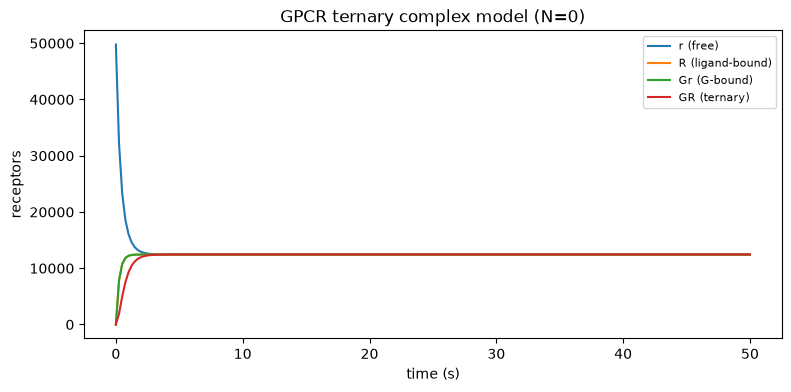

equilibrium (r,R,Gr,GR) = [12442, 12442, 12442, 12442]


In [1]:
import warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from ecell4.prelude import *

L, G = 1.0, 1.0                       # 入力: リガンド・G タンパク質 濃度
kl0 = ka0 = kg0 = kb0 = 1.0            # 会合速度 (= d/K, 既定で 1)
dl0 = da0 = dg0 = db0 = 1.0            # 解離速度 1/s
with reaction_rules():
    r  == R  | (kl0 * L, dl0)          # 受容体にリガンド結合
    R  == GR | (ka0 * G, da0)          # さらに G タンパク質結合 -> 三者複合体
    r  == Gr | (kg0 * G, dg0)          # 先に G タンパク質結合
    Gr == GR | (kb0 * L, db0)          # そこへリガンド結合 -> 三者複合体
m = get_model()

r0 = 49770   # 受容体数 = T(4.977/um^2) x A(10000 um^2)
a = run_simulation(50.0, ndiv=200, model=m, y0={'r': r0}, species_list=['r','R','Gr','GR']).as_array()
plt.figure(figsize=(9,4))
for i,lab in enumerate(['r (free)','R (ligand-bound)','Gr (G-bound)','GR (ternary)'],1):
    plt.plot(a[:,0], a[:,i], label=lab)
plt.xlabel('time (s)'); plt.ylabel('receptors'); plt.legend(fontsize=8); plt.title('GPCR ternary complex model (N=0)'); plt.show()
print('equilibrium (r,R,Gr,GR) =', [round(x) for x in a[-1][1:]])

## 読み取り と 上位モデル(N=1..5)

N=0 では 4 状態が（既定パラメータでは対称に）平衡へ向かう。三者複合体 `GR` が活性化シグナルに相当する。

公式例題はこれを **N=1..5 の多量体**（受容体が二量体・三量体…と会合し、各サブユニットがリガンド/G タンパク質を結合する）へ拡張し、
`ParConfigs` クラスでパラメータを、`run_N0()`〜`run_N5()` で各次数のシミュレーションを回して、**オリゴマー化が用量応答（活性化曲線）に与える影響**を比較する。
サイト・状態が増えて反応が組合せ的に膨らむため、ルールベース（o10 EGFR 参照）とも相性がよい。完全なコードは出典ページ参照。

**要点**: 受容体オリゴマー化の程度（N）を変えて、GPCR 活性化のアロステリー/協同性をモデル比較する枠組み。